In [1]:
import os
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
import random
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from facenet_pytorch import InceptionResnetV1
from minusface import MinusBackbone
from torch.optim.lr_scheduler import CosineAnnealingLR
import wandb
import pandas as pd
import tqdm
from insightface.app import FaceAnalysis
from datasets import load_from_disk
ds = load_from_disk("celeba_faceid_embeddings_val")

embeddings = {}
for sample in ds:
    img_name = sample["image_name"]
    embedding = sample["embedding"]
    if embedding is not None:
        embeddings[img_name] = torch.tensor(embedding[0]).unsqueeze(0)

import cv2
from insightface.app import FaceAnalysis  
import torch



/home/user/miniconda/envs/minus_face/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
from onnx2torch import convert
device = "cuda:1"
onnx_model_path = "model.onnx"
student = convert(onnx_model_path).to(device)

conversion_model = MinusBackbone(mode='stage1')
conversion_model.load_state_dict(torch.load("../../../../minusface_stage1.pth", map_location='cpu'))
conversion_model = conversion_model.eval().to(device)

tf_teacher = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

tf_student = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

tf_conv = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])


In [3]:
student.load_state_dict(torch.load("student.pth.bak", map_location='cpu'))

<All keys matched successfully>

In [4]:

tf_teacher = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

tf_student = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

tf_conv = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor()
])

In [5]:
def convert_batch(conv_raw):
    conv_raw = conv_raw.to(device) 
    with torch.no_grad():
        out = conversion_model(conv_raw)
    out = out[5]
    out = out.permute(0,2,3,1).cpu().numpy()
    out = (out - out.min(axis=(1,2,3),keepdims=True)) / (out.max(axis=(1,2,3),keepdims=True) - out.min(axis=(1,2,3),keepdims=True) + 1e-8)
    out = np.clip(out[...,:3],0,1)
    out = (out*255).astype(np.uint8)
    imgs = [Image.fromarray(x) for x in out]
    final = torch.stack([tf_student(im) for im in imgs]).to(device)
    return final, imgs


In [6]:
import cv2
from insightface.app import FaceAnalysis
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/user/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size

In [7]:
images = os.listdir("val")

In [8]:
# image = cv2.imread("CHINA PASSPORT & VISA.jpg")
# # image = cv2.imread("val/" + images[0])
# faces = app.get(image)

In [9]:
# box = faces[0]["bbox"]
# # crop and align
# x1, y1, x2, y2 = map(int, box)
# face_img = image[y1:y2, x1:x2]
# face_img = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
# face_pil = Image.fromarray(face_img)
# face_pil

In [10]:
idx = 12
pil_image = Image.open("val/" + images[idx]).convert("RGB")
c_img = tf_conv(pil_image).unsqueeze(0).to(device)

In [11]:
"val/" + images[idx]

'val/001654.jpg'

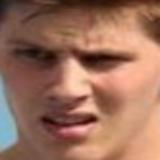

In [12]:
pil_image 

In [13]:
s_img, imgs = convert_batch(c_img)

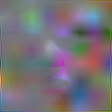

In [14]:
imgs[0] # i know, this is not the crop used in training

In [ ]:
student = student.eval().to(device)
s_emb = student(s_img)  

In [16]:
s_emb = s_emb / s_emb.norm()

In [17]:
# faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)

In [18]:
# faceid_embeds.norm(), s_emb.norm(), faceid_embeds.shape, s_emb.shape

In [19]:
# faceid_embeds.to(device) @ s_emb.T  

In [20]:
# torch.save(faceid_embeds, "faceid_embeds.pt") 
torch.save(s_emb, "embedding.pt")

In [21]:
torch.save(embeddings[list(embeddings.keys())[0]], "faceid_embeds_database.pt")

In [22]:
list(embeddings.keys())[0]

'022668.jpg'